In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

## Load and Visualize the data

In [28]:
train_path = '../data/processed/train.npz'
test_path = '../data/processed/test.npz'

def load_data(npz_path):
    data = np.load(npz_path)
    signals = data['signals']
    labels = data['labels']

    return signals, labels

signals, labels = load_data(train_path)

In [64]:
bin_labels = labels.any(axis=1).astype(np.int8)
arousals = signals[bin_labels == 1]
non_arousals = signals[bin_labels == 0]

print("Arousal Events: ", arousals.shape)
print("Non Arousal Events: ", non_arousals.shape)

Arousal Events:  (2822, 2, 3500)
Non Arousal Events:  (5567, 2, 3500)


<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
C:\Users\IDMOP0\AppData\Local\Temp\ipykernel_9548\3229639557.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Channel {ch_names[ch]}: Event-Locked Signal $\mu \pm \sigma$ Variance Analysis')
C:\Users\IDMOP0\AppData\Local\Temp\ipykernel_9548\3229639557.py:32: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Amplitude ($\mu$V)')


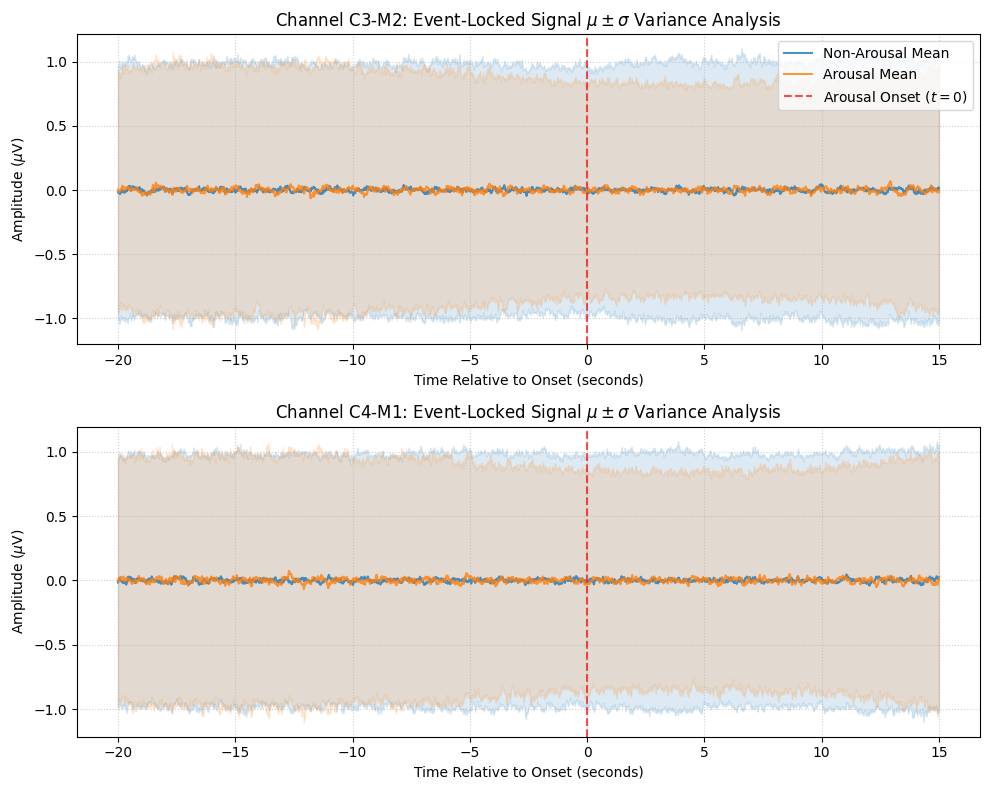

In [66]:
mean_arousal = arousals.mean(axis=0)
std_arousal = arousals.std(axis=0)

mean_non = non_arousals.mean(axis=0)
std_non = non_arousals.std(axis=0)

fs = 100
time = np.linspace(-20, 15, 3500)

# Channel mapping for labels
ch_names = ["C3-M2", "C4-M1"]

plt.figure(figsize=(10, 8))
for ch in range(2):
    # Create a 2x1 grid of subplots dynamically without explicitly instantiating a figure object
    plt.subplot(2, 1, ch + 1)
    
    plt.plot(time, mean_non[ch], label='Non-Arousal Mean', color='tab:blue', alpha=0.8, linewidth=1.5)
    plt.fill_between(time, mean_non[ch] - std_non[ch], mean_non[ch] + std_non[ch], 
                     color='tab:blue', alpha=0.15)
    
    plt.plot(time, mean_arousal[ch], label='Arousal Mean', color='tab:orange', alpha=0.8, linewidth=1.5)
    plt.fill_between(time, mean_arousal[ch] - std_arousal[ch], mean_arousal[ch] + std_arousal[ch], 
                     color='tab:orange', alpha=0.15)
    
    # Draw a vertical marker pinpointing the exact clinical onset moment
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Arousal Onset ($t=0$)')
    
    # Labeling and Clean formatting
    plt.title(f'Channel {ch_names[ch]}: Event-Locked Signal $\mu \pm \sigma$ Variance Analysis')
    plt.xlabel('Time Relative to Onset (seconds)')
    plt.ylabel('Amplitude ($\mu$V)')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    if ch == 0:
        plt.legend(loc='upper right')

plt.tight_layout()
plt.show()